In [1]:
#Partie 1: Charger et masquer WorldCover
#___________________________________________________________

# Aperçu de la zone d'étude

import datacube

from deafrica_tools.plotting import display_map

 

# Coordonnées du centre et zone tampon (degrés)

lon, lat, buf = 23.0, 0.0, 11.0

lon_range = (lon - buf, lon + buf)

lat_range = (lat + buf, lat - buf)

# Afficher la zone d'étude

display_map(x=lon_range, y=lat_range)

print('Lon:', lon_range, 'Lat:', lat_range)

# Définir la période d'analyse

time_window = ('2020-07-01', '2021-07-01')

# Définir des paramètres de requête communs (y compris time_window défini ailleurs)

common_query = {

    'x': lon_range,

    'y': lat_range,

    'time': time_window,

    'output_crs': 'EPSG:6933',

    'resolution': (-500, 500),

    'resampling': 'mode',

    'measurements': ['classification']

}
#___________________________________________________________

Lon: (12.0, 34.0) Lat: (11.0, -11.0)


In [2]:
##1.4.1: Définir les produits et les timestamps à mi-année
#____________________________________________
# 1. Définir les produits et les timestamps correspondant au milieu de l’année

wc_products = {

    'esa_worldcover_2020': '2020-07-01',

    'esa_worldcover_2021': '2021-07-01'

}

# 2. La classe forêt dans WorldCover correspond à la classe 10 (couvert arboré) 

forest_id = 10

#___________________________________________________________

# Pourquoi ? Nous utilisons le 1er juillet comme point de référence afin d’éviter les effets saisonniers et garantir la cohérence des comparaisons.

In [3]:
## 1.4.2: Boucler sur chaque produit pour le chargement et l’application du masque
#____________________________________________
# 3. Charger et masquer chaque année dans une liste
annual_masks = []

dc = datacube.Datacube(app='WorldCover_masking')

 

for prod, ts in wc_products.items():

    ds = dc.load(

        product=prod,

        time=ts,

        **{k: v for k, v in common_query.items() if k != 'time'}

    ).squeeze()

    # La variable de données est généralement 'Map' ou similaire ; prendre la première disponible

    var = next(iter(ds.data_vars))

    arr = ds[var].values


    # Créer un masque booléen pour la classe forêt

    mask = (arr == forest_id)

    annual_masks.append((prod.split('_')[-1], mask))

#___________________________________________________________

#Astuce 💡: Si les formes obtenues sont inattendues, vérifiez votre boîte englobante common_q et le système de coordonnées (CRS)

In [4]:
## Partie 2: Visualiser et calculer le masque de perte
##1.4.3: Extraire les années et les masques, puis calculer les pertes
#___________________________________________________________
import matplotlib.pyplot as plt

# Vérification
if 'annual_masks' not in globals():
    raise ValueError("Exécute d'abord la cellule qui crée annual_masks")

import numpy as np

years, masks = zip(*annual_masks)

mask2020, mask2021 = masks

# Détecter les pixels qui sont passés de la catégorie forêt à la catégorie non-forêt entre 2020 et 2021.

loss_mask = np.logical_and(mask2020, ~mask2021)

print("Calcul OK ✅")

#___________________________________________________________


Calcul OK ✅


Text(0.5, 0.98, 'Forêt et perte selon ESA WorldCover (2020 vs 2021)')

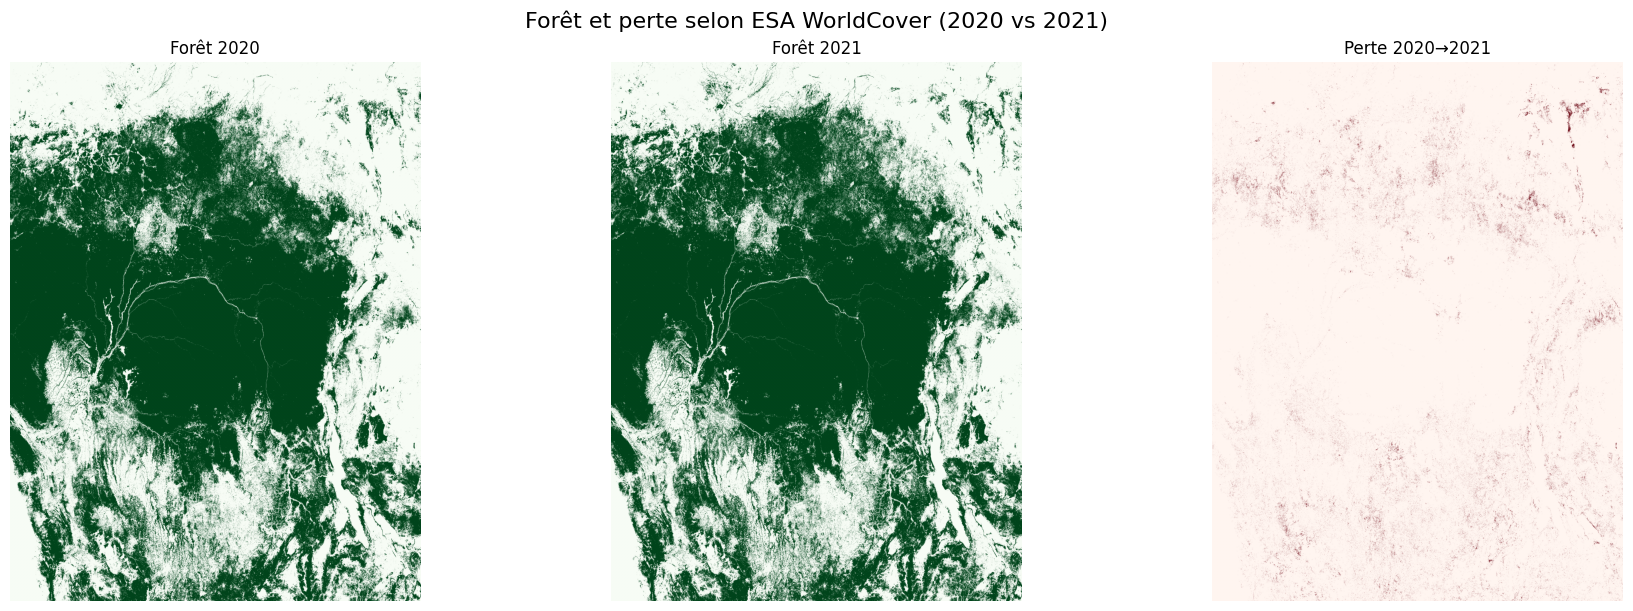

In [5]:
#Pourquoi ? Cela permet d’identifier précisément les pixels forestiers en 2020 qui ne le sont plus en 2021.

#1.4.4: Afficher côte à côte
#___________________________________________________________
# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# 2020

axes[0].imshow(mask2020, cmap='Greens')

axes[0].set_title("Forêt 2020")

axes[0].axis('off')

# 2021

axes[1].imshow(mask2021, cmap='Greens')

axes[1].set_title("Forêt 2021")

axes[1].axis('off')

# Perte

axes[2].imshow(loss_mask, cmap='Reds')

axes[2].set_title('Perte 2020→2021')

axes[2].axis('off')

plt.suptitle("Forêt et perte selon ESA WorldCover (2020 vs 2021)", fontsize=16)

#___________________________________________________________
#Résultat attendu : Vous devriez voir trois panneaux : forêt 2020 (en vert), forêt 2021 (en vert), et perte (en rouge).
#Figure 1.4.1:  Vue côte à côte du couvert forestier en 2020 et 2021, ainsi que des pertes détectées.

✅ GIF sauvegardé: esa_worldcover_deforestation_2020_2021.gif


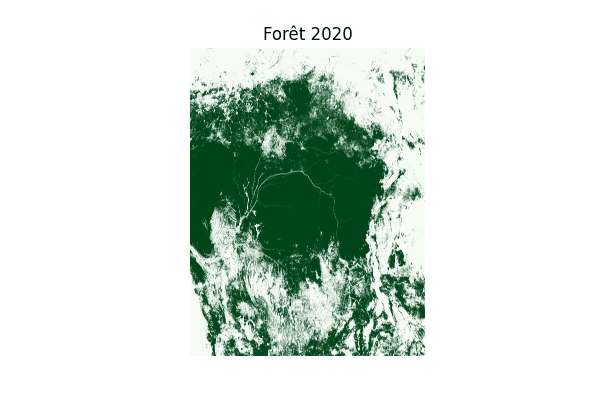

In [6]:
## Partie 3: Animer le changement
## 1.4.5: Convertir chaque masque en une image RGB
#___________________________________________________________
# Créer et enregistrer un GIF à deux cadres sur la déforestation
 
import imageio
from IPython.display import Image, display

images = []

for year, mask in annual_masks:

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.imshow(mask, cmap='Greens')

    ax.set_title(f"Forêt {year}")

    ax.axis('off')

    fig.canvas.draw()

 

    buf, (w, h) = fig.canvas.print_to_buffer()

    arr = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 4))[..., :3]

    images.append(arr)

    plt.close(fig)

 

# Ajouter le masque de perte en tant que troisième cadre

 

fig, ax = plt.subplots(figsize=(6, 4))

ax.imshow(loss_mask, cmap='Reds')

ax.set_title("Perte 2020→2021")

ax.axis('off')

fig.canvas.draw()

buf, (w, h) = fig.canvas.print_to_buffer()

loss_arr = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 4))[..., :3]

images.append(loss_arr)

plt.close(fig)

 

# Enregistrer le GIF

gif_path = 'esa_worldcover_deforestation_2020_2021.gif'

imageio.mimsave(gif_path, images, fps=1)

print(f"✅ GIF sauvegardé: {gif_path}")
# ✅ AFFICHAGE DU GIF
display(Image(filename=gif_path))
#___________________________________________________________

#Figure 1.4.2: GIF animé illustrant la déforestation entre 2020 et 2021.

In [7]:
## 1.5.1: Calculer la surface annuelle de perte forestière
#___________________________________________________________
# Calculer la surface annuelle de perte forestière
pixel_ha = (30*30) / 10000  # 0,09 ha par pixel de 30 m

annual_masks.sort(key=lambda x: x[0])  # assurer l'ordre chronologique

loss_areas = {}

for i, (yr, mask) in enumerate(annual_masks):

    if i==0:

        loss_areas[yr] = 0.0

    else:

        prev = annual_masks[i-1][1]

        loss = np.logical_and(prev, ~mask)

        loss_areas[yr] = np.count_nonzero(loss) * pixel_ha

 

import pandas as pd

pd.Series(loss_areas, name='Annual_Loss_ha')  # 📋 Tableau 1.5.1 (colonne de gauche)

#___________________________________________________________


2020        0.00
2021    33769.35
Name: Annual_Loss_ha, dtype: float64

In [8]:
## 1.5.2: Estimate Annual Carbon Loss
#___________________________________________________________
# Convertir la surface perdue en perte de carbone
biomass_density = 150   # t de matière sèche/ha (à ajuster selon la biomasse locale)

carbon_fraction = 0.5   # 50 % de la biomasse est constituée de carbone

 

carbon_loss = {

    yr: ha * biomass_density * carbon_fraction

    for yr, ha in loss_areas.items()

}


pd.Series(carbon_loss, name='Annual_Carbon_Loss_tC')  # 📋 Tableau 1.5.1 (colonne de droite)

#___________________________________________________________
#Astuce 💡: remplacez les valeurs de densité de biomasse par défaut par celles propres à chaque type de forêt, si nécessaire.

2020          0.00
2021    2532701.25
Name: Annual_Carbon_Loss_tC, dtype: float64

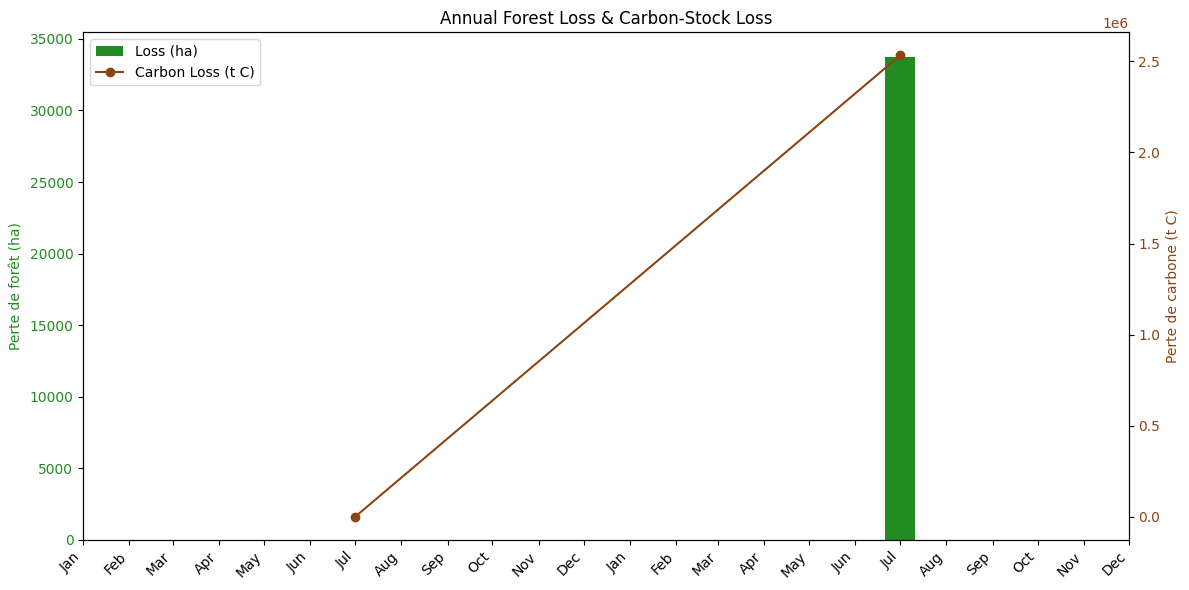

In [9]:
## 1.5.3: Plot Area & Carbon Loss
#___________________________________________________________
# Graphique combiné : barres (surface) et ligne (carbone) 
import matplotlib.dates as mdates


yrs = sorted(loss_areas)

dates = pd.to_datetime([f"{yr}-07-01" for yr in yrs])

areas = [loss_areas[yr] for yr in yrs]

carb  = [carbon_loss[yr] for yr in yrs]
 

fig, ax1 = plt.subplots(figsize=(12,6))


#  Barres : surface de forêt perdue

ax1.bar(dates, areas, width=20, color='forestgreen', label='Loss (ha)')

ax1.set_ylabel("Perte de forêt (ha)", color="forestgreen")

ax1.tick_params(axis='y', labelcolor='forestgreen')

 

# Ligne : perte de carbone

ax2 = ax1.twinx()

ax2.plot(dates, carb, color='saddlebrown', marker='o', label='Carbon Loss (t C)')

ax2.set_ylabel('Perte de carbone (t C)', color='saddlebrown')

ax2.tick_params(axis='y', labelcolor='saddlebrown')

# Mise en forme de l’axe des X

ax1.set_xlim(dates[0].replace(month=1), dates[-1].replace(month=12))

ax1.xaxis.set_major_locator(mdates.MonthLocator())

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Légende et titre

handles1, labels1 = ax1.get_legend_handles_labels()

handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc='upper left')

plt.title('Annual Forest Loss & Carbon-Stock Loss')  # 📍 Figure 1.5.1

plt.tight_layout()

plt.show()

#___________________________________________________________

#Réflexion ❓: comment vos estimations de carbone changeraient-elles si vous utilisiez une densité de biomasse de 200 t de matière sèche/ha ?

#Figure 1.5.1: Combined bar and line chart showing annual forest loss and carbon-stock loss.